# An MLP on the digits, trained with hand-written backprop

`MLPClassifier` contains no autograd: the four backprop equations are written out by hand
and checked against finite differences in the test suite. Here it trains on the 8x8 digits
in a few seconds of CPU time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from scratchlearn.neural import MLPClassifier
from scratchlearn.metrics import confusion_matrix, accuracy_score
from scratchlearn.model_selection import train_test_split

X, y = load_digits(return_X_y=True)
X = X / 16.0
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

net = MLPClassifier(hidden_layer_sizes=(64,), lr=0.1, epochs=60, random_state=0)
net.fit(X_train, y_train)
print(f"test accuracy: {net.score(X_test, y_test):.4f}")

test accuracy: 0.9644


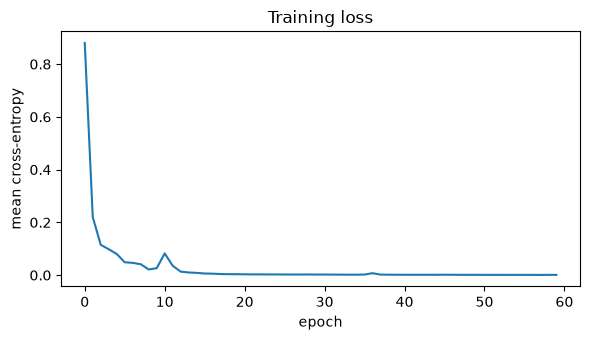

In [2]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(net.loss_history_)
ax.set_xlabel("epoch")
ax.set_ylabel("mean cross-entropy")
ax.set_title("Training loss")
plt.tight_layout()

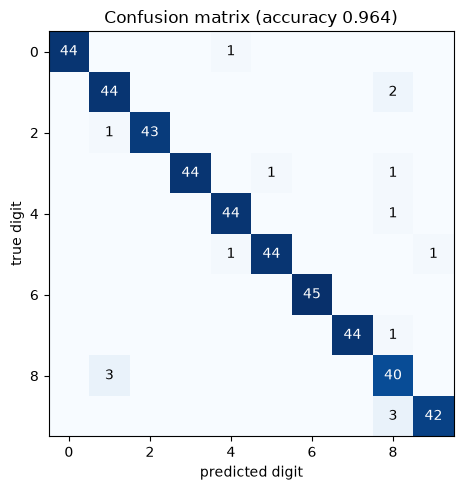

In [3]:
pred = net.predict(X_test)
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(cm, cmap="Blues")
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            colour = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=colour)
ax.set_xlabel("predicted digit")
ax.set_ylabel("true digit")
ax.set_title(f"Confusion matrix (accuracy {accuracy_score(y_test, pred):.3f})")
plt.tight_layout()

The remaining mistakes sit between the usual confusable pairs of digits. A convolutional
network would do better by exploiting the 2-D structure of the images, but for a fully
connected model built from four matrix equations this is a respectable place to stop.